In [9]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from urllib.parse import urljoin
import json
import re

BASE_URL = "https://books.toscrape.com/"

books = []

for page in range(1, 51):
    url = BASE_URL + f"catalogue/page-{page}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    for book in soup.select("article.product_pod"):
        link = urljoin(BASE_URL, book.h3.a["href"])
        title = book.h3.a["title"]
        price = book.select_one(".price_color").text.strip()
        rating = book.select_one(".star-rating")["class"][1]
        availability = book.select_one(".availability").text.strip()

        detail_response = requests.get(link)
        detail_soup = BeautifulSoup(detail_response.text, "html.parser")

        category = detail_soup.select("ul.breadcrumb li")[-1].text.strip()

        description = ""
        desc = detail_soup.select_one("#product_description")
        if desc and desc.find_next_sibling():
            description = desc.find_next_sibling().text.strip()

        table = {}
        for row in detail_soup.select("table.table tr"):
            cells = row.find_all("td")
            if len(cells) == 2:
                table[cells[0].text.strip()] = cells[1].text.strip()

        books.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability,
            "Category": category,
            "Description": description,
            "UPC": table.get("UPC", ""),
            "Product Type": table.get("Product Type", ""),
            "Tax": table.get("Tax", ""),
            "Reviews": table.get("Number of reviews", ""),
            "URL": link
        })

print("Books scraped:", len(books))

with open("books.json", "w", encoding="utf-8") as f:
    json.dump(books, f, indent=4, ensure_ascii=False)

df = pd.DataFrame(books)

print("\nShape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

df["Price"] = df["Price"].str.replace("£", "", regex=False).astype(float)

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

df["Availability_Count"] = df["Availability"].str.extract(r"(\d+)").astype(float)

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce").fillna(0)

df["Tax"] = df["Tax"].str.replace("£", "", regex=False).astype(float)

df["Title_Length"] = df["Title"].str.len()

df["Description_Length"] = df["Description"].str.len()

df["Price_Per_Rating"] = df["Price"] / df["Rating"]

df["Availability_Status"] = np.where(
    df["Availability_Count"] > 0,
    "Available",
    "Unavailable"
)

df["Price_Normalized"] = (
    (df["Price"] - df["Price"].min()) /
    (df["Price"].max() - df["Price"].min())
)

print("\nAfter cleaning and feature engineering:")
print(df.head())

print("\nData types:")
print(df.dtypes)

plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=20)
plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Prices")
plt.show()

plt.figure(figsize=(8,5))
df["Rating"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Books by Rating")
plt.show()

plt.figure(figsize=(10,5))
df["Category"].value_counts().head(10).plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Number of Books")
plt.title("Top 10 Book Categories")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["Price"], df["Rating"])
plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

category_price = df.groupby("Category")["Price"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
category_price.plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.title("Average Price of Top Categories")
plt.xticks(rotation=45)
plt.show()

print("\nBusiness Insights:")
print("1. Average book price:", round(df["Price"].mean(), 2))
print("2. Most common rating:", df["Rating"].mode()[0])
print("3. Most common category:", df["Category"].mode()[0])
print("4. Most expensive book:", df.loc[df["Price"].idxmax(), "Title"])
print("5. Cheapest book:", df.loc[df["Price"].idxmin(), "Title"])

df.to_csv("books.csv", index=False)

print("\nSaved: books.json")
print("Saved: books.csv")

IndexError: list index out of range

In [10]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

url = "https://www.imdb.com/search/title/?title_type=feature&sort=num_votes,desc"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

movies = []

items = soup.select("li.ipc-metadata-list-summary-item")

for item in items:
    title_tag = item.select_one("h3")
    title = title_tag.text.strip() if title_tag else ""

    metadata = item.select("span.ipc-metadata-list-summary-item__li")

    year = metadata[0].text.strip() if len(metadata) > 0 else ""
    duration = metadata[1].text.strip() if len(metadata) > 1 else ""
    certificate = metadata[2].text.strip() if len(metadata) > 2 else ""

    rating_tag = item.select_one("span.ipc-rating-star--rating")
    rating = rating_tag.text.strip() if rating_tag else ""

    votes_tag = item.select_one("span.ipc-rating-star--voteCount")
    votes = votes_tag.text.strip() if votes_tag else ""

    description_tag = item.select_one("div.ipc-html-content-inner-div")
    description = description_tag.text.strip() if description_tag else ""

    movies.append({
        "Title": title,
        "Year": year,
        "Duration": duration,
        "Certificate": certificate,
        "Rating": rating,
        "Votes": votes,
        "Description": description
    })

df = pd.DataFrame(movies)

print("Movies scraped:", len(df))
print(df.head())

df["Year"] = pd.to_numeric(
    df["Year"].str.extract(r"(\d{4})")[0],
    errors="coerce"
)

df["Duration_Minutes"] = pd.to_numeric(
    df["Duration"].str.extract(r"(\d+)")[0],
    errors="coerce"
)

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df["Votes"] = (
    df["Votes"]
    .str.replace(",", "", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("K", "000", regex=False)
    .str.replace("M", "000000", regex=False)
)

def convert_votes(x):
    try:
        if "K" in x:
            return float(x.replace("K", "")) * 1000
        elif "M" in x:
            return float(x.replace("M", "")) * 1000000
        else:
            return float(x)
    except:
        return np.nan

df["Votes"] = df["Votes"].apply(convert_votes)

df.drop_duplicates(inplace=True)

df["Title_Length"] = df["Title"].str.len()

df["Description_Length"] = df["Description"].str.len()

df["Rating_Squared"] = df["Rating"] ** 2

df["Votes_Log"] = np.log1p(df["Votes"])

df["Popularity_Score"] = df["Rating"] * np.log1p(df["Votes"])

df["Rating_Normalized"] = (
    (df["Rating"] - df["Rating"].min()) /
    (df["Rating"].max() - df["Rating"].min())
)

df["Votes_Normalized"] = (
    (df["Votes"] - df["Votes"].min()) /
    (df["Votes"].max() - df["Votes"].min())
)

df["Duration_Normalized"] = (
    (df["Duration_Minutes"] - df["Duration_Minutes"].min()) /
    (df["Duration_Minutes"].max() - df["Duration_Minutes"].min())
)

df["Year_Normalized"] = (
    (df["Year"] - df["Year"].min()) /
    (df["Year"].max() - df["Year"].min())
)

print("\nMissing values:")
print(df.isnull().sum())

print("\nShape:", df.shape)

plt.figure(figsize=(8,5))
plt.hist(df["Rating"].dropna(), bins=10)
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.title("Distribution of IMDb Ratings")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["Year"].dropna(), bins=20)
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.title("Movies by Release Year")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["Rating"], df["Votes"])
plt.xlabel("Rating")
plt.ylabel("Votes")
plt.title("Rating vs Number of Votes")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["Duration_Minutes"], df["Rating"])
plt.xlabel("Duration")
plt.ylabel("Rating")
plt.title("Duration vs Rating")
plt.show()

year_rating = df.groupby("Year")["Rating"].mean()

plt.figure(figsize=(10,5))
year_rating.plot()
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.title("Average Rating by Year")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["Duration_Minutes"].dropna(), bins=20)
plt.xlabel("Duration in Minutes")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Durations")
plt.show()

print("\nInsights:")
print("1. Average rating:", round(df["Rating"].mean(), 2))
print("2. Highest rated movie:", df.loc[df["Rating"].idxmax(), "Title"])
print("3. Most voted movie:", df.loc[df["Votes"].idxmax(), "Title"])
print("4. Average duration:", round(df["Duration_Minutes"].mean(), 2))
print("5. Oldest movie year:", int(df["Year"].min()))
print("6. Newest movie year:", int(df["Year"].max()))

df.to_csv("imdb_movies.csv", index=False)

print("\nSaved: imdb_movies.csv")

Movies scraped: 0
Empty DataFrame
Columns: []
Index: []


KeyError: 'Year'

Recipes collected: 39
                  Recipe  Region  \
0  Dassana’s Veg Recipes  Indian   
1           Recipe Index  Indian   
2      Breakfast Recipes  Indian   
3   Indian Curry Recipes  Indian   
4           Cake Recipes  Indian   

                                         Ingredients Cooking_Method Nutrition  \
0  Home | Recipe Index Expand Breakfast Curries C...         Frying      2026   
1  Home | Recipe Index Expand Breakfast Curries C...          Other             
2  Home | Recipe Index Expand Breakfast Curries C...         Frying             
3  Home | Recipe Index Expand Breakfast Curries C...          Other             
4  Home | Recipe Index Expand Breakfast Curries C...          Other             

  GI_Status                                                URL  
0   Unknown                 https://www.vegrecipesofindia.com/  
1   Unknown         https://www.vegrecipesofindia.com/recipes/  
2   Unknown  https://www.vegrecipesofindia.com/recipes/indi...  
3   Unknown  h

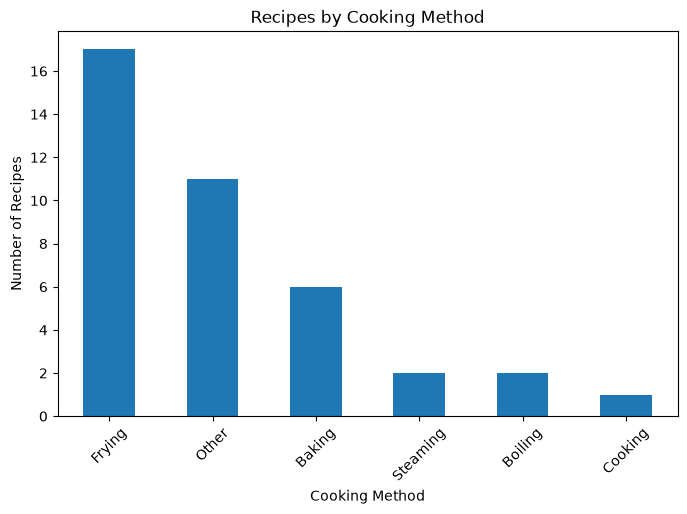

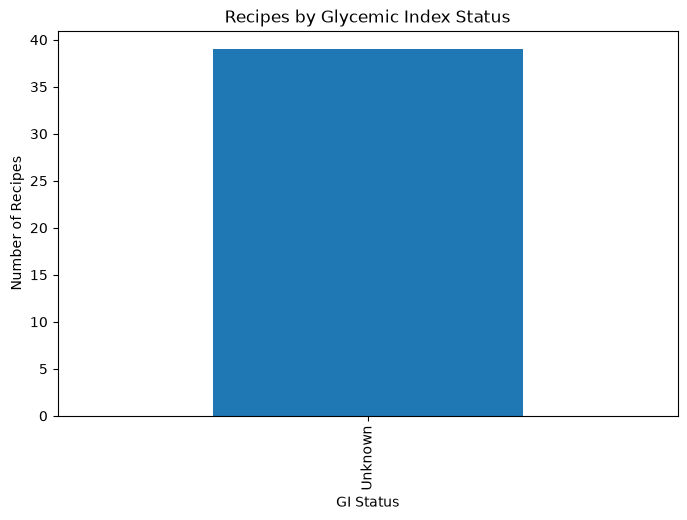

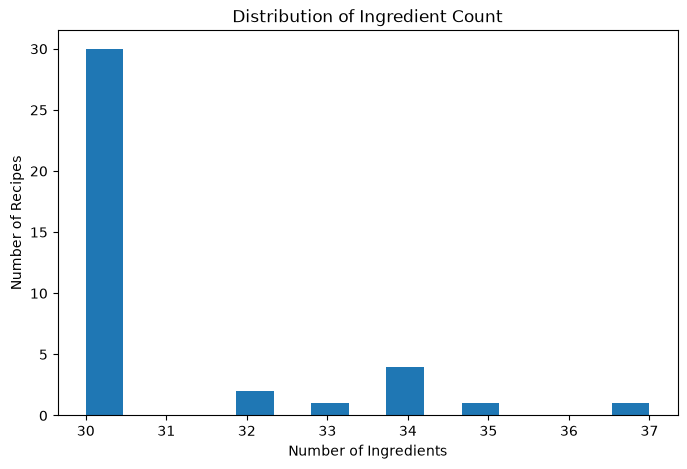

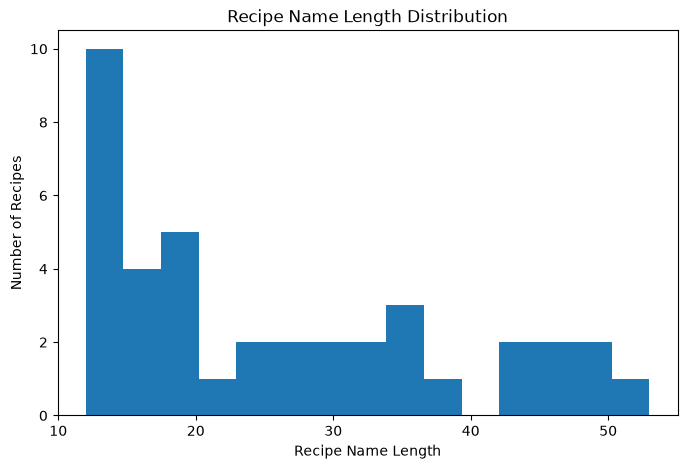

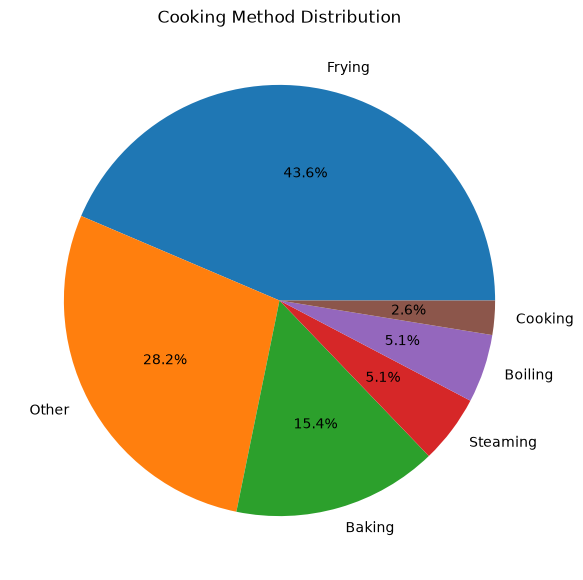

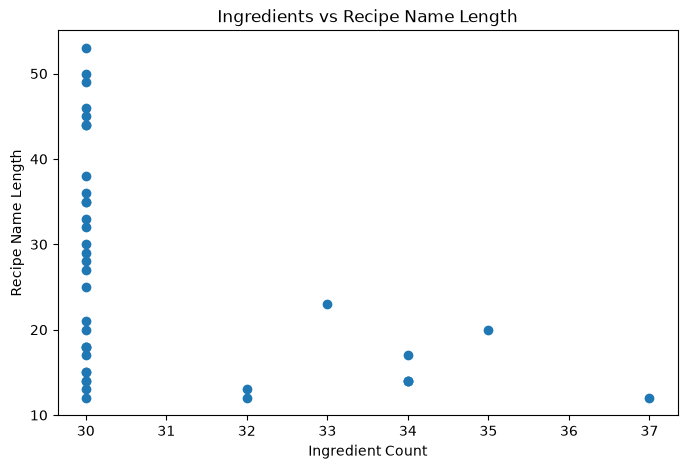

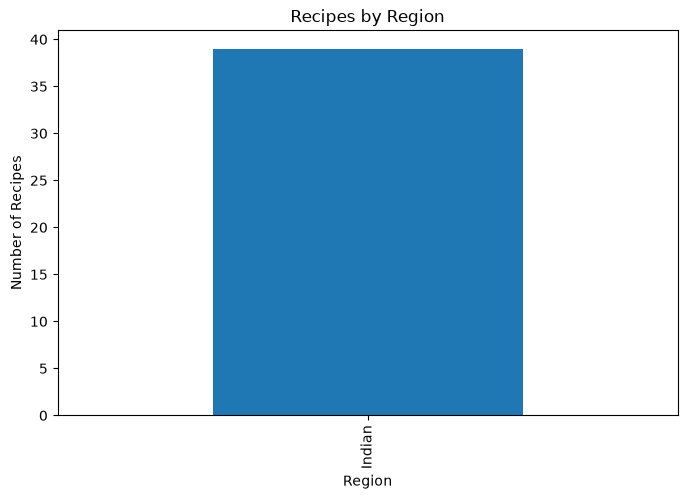

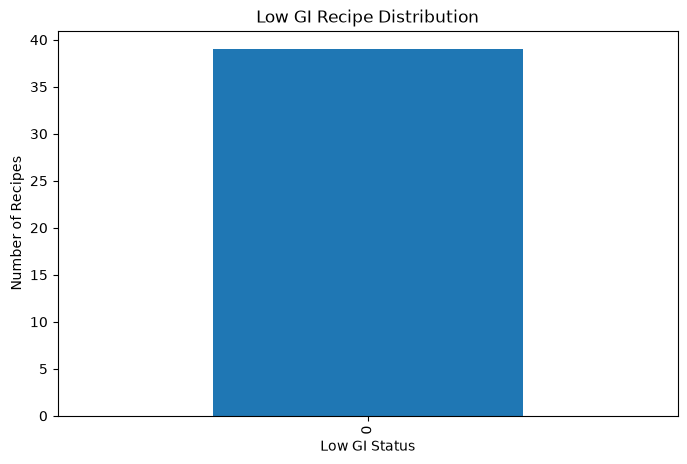


Insights:
1. Most common cooking method: Frying
2. Average ingredient count: 30.9
3. Most common GI status: Unknown
4. Recipe with most ingredients: Rice Recipes
5. Average recipe name length: 25.97

Saved: indian_recipes.csv


In [11]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

BASE_URL = "https://www.vegrecipesofindia.com/"

urls = [
    "https://www.vegrecipesofindia.com/recipes/indian-recipes/"
]

recipes = []

for page_url in urls:
    response = requests.get(
        page_url,
        headers={"User-Agent": "Mozilla/5.0"}
    )

    soup = BeautifulSoup(response.text, "html.parser")

    links = soup.select("a")

    recipe_links = []

    for link in links:
        href = link.get("href")
        if href and "vegrecipesofindia.com" in href:
            recipe_links.append(href)

    recipe_links = list(dict.fromkeys(recipe_links))

    for link in recipe_links[:200]:
        try:
            r = requests.get(
                link,
                headers={"User-Agent": "Mozilla/5.0"},
                timeout=10
            )

            s = BeautifulSoup(r.text, "html.parser")

            title_tag = s.find("h1")
            title = title_tag.text.strip() if title_tag else ""

            text = s.get_text(" ", strip=True)

            ingredients = []

            for li in s.select("li"):
                value = li.get_text(" ", strip=True)
                if len(value) > 3:
                    ingredients.append(value)

            ingredients = " | ".join(ingredients[:30])

            cooking_method = ""

            if "baked" in text.lower():
                cooking_method = "Baking"
            elif "fried" in text.lower():
                cooking_method = "Frying"
            elif "steamed" in text.lower():
                cooking_method = "Steaming"
            elif "boiled" in text.lower():
                cooking_method = "Boiling"
            elif "cooked" in text.lower():
                cooking_method = "Cooking"
            else:
                cooking_method = "Other"

            region = "Indian"

            nutrition = ""

            nutrition_patterns = [
                r"calories.*?(\d+)",
                r"protein.*?(\d+)",
                r"carbohydrates.*?(\d+)"
            ]

            for pattern in nutrition_patterns:
                match = re.search(pattern, text, re.I)
                if match:
                    nutrition = match.group(1)
                    break

            gi_status = "Unknown"

            if "low glycemic" in text.lower():
                gi_status = "Low"
            elif "high glycemic" in text.lower():
                gi_status = "High"
            elif "glycemic" in text.lower():
                gi_status = "Medium"

            recipes.append({
                "Recipe": title,
                "Region": region,
                "Ingredients": ingredients,
                "Cooking_Method": cooking_method,
                "Nutrition": nutrition,
                "GI_Status": gi_status,
                "URL": link
            })

        except:
            continue

        if len(recipes) >= 200:
            break

    if len(recipes) >= 200:
        break

df = pd.DataFrame(recipes)

print("Recipes collected:", len(df))
print(df.head())

df.drop_duplicates(subset=["Recipe"], inplace=True)

df["Recipe"] = df["Recipe"].fillna("Unknown")
df["Ingredients"] = df["Ingredients"].fillna("")
df["Region"] = df["Region"].fillna("Unknown")
df["Cooking_Method"] = df["Cooking_Method"].fillna("Other")
df["GI_Status"] = df["GI_Status"].fillna("Unknown")

df["Ingredient_Count"] = df["Ingredients"].apply(
    lambda x: len(x.split("|")) if x else 0
)

df["Recipe_Name_Length"] = df["Recipe"].str.len()

df["Ingredient_Text_Length"] = df["Ingredients"].str.len()

df["Is_Low_GI"] = np.where(
    df["GI_Status"].str.lower() == "low",
    1,
    0
)

df["Is_Vegetarian"] = 1

df["Ingredient_Count_Normalized"] = (
    (df["Ingredient_Count"] - df["Ingredient_Count"].min()) /
    (df["Ingredient_Count"].max() - df["Ingredient_Count"].min()
     if df["Ingredient_Count"].max() != df["Ingredient_Count"].min() else 1)
)

df["Recipe_Length_Normalized"] = (
    (df["Recipe_Name_Length"] - df["Recipe_Name_Length"].min()) /
    (df["Recipe_Name_Length"].max() - df["Recipe_Name_Length"].min()
     if df["Recipe_Name_Length"].max() != df["Recipe_Name_Length"].min() else 1)
)

print("\nMissing values:")
print(df.isnull().sum())

print("\nShape:", df.shape)

plt.figure(figsize=(8,5))
df["Cooking_Method"].value_counts().plot(kind="bar")
plt.xlabel("Cooking Method")
plt.ylabel("Number of Recipes")
plt.title("Recipes by Cooking Method")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
df["GI_Status"].value_counts().plot(kind="bar")
plt.xlabel("GI Status")
plt.ylabel("Number of Recipes")
plt.title("Recipes by Glycemic Index Status")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["Ingredient_Count"], bins=15)
plt.xlabel("Number of Ingredients")
plt.ylabel("Number of Recipes")
plt.title("Distribution of Ingredient Count")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["Recipe_Name_Length"], bins=15)
plt.xlabel("Recipe Name Length")
plt.ylabel("Number of Recipes")
plt.title("Recipe Name Length Distribution")
plt.show()

method_counts = df["Cooking_Method"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    method_counts.values,
    labels=method_counts.index,
    autopct="%1.1f%%"
)
plt.title("Cooking Method Distribution")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(
    df["Ingredient_Count"],
    df["Recipe_Name_Length"]
)
plt.xlabel("Ingredient Count")
plt.ylabel("Recipe Name Length")
plt.title("Ingredients vs Recipe Name Length")
plt.show()

plt.figure(figsize=(8,5))
df["Region"].value_counts().head(10).plot(kind="bar")
plt.xlabel("Region")
plt.ylabel("Number of Recipes")
plt.title("Recipes by Region")
plt.show()

plt.figure(figsize=(8,5))
df["Is_Low_GI"].value_counts().plot(kind="bar")
plt.xlabel("Low GI Status")
plt.ylabel("Number of Recipes")
plt.title("Low GI Recipe Distribution")
plt.show()

print("\nInsights:")
print("1. Most common cooking method:",
      df["Cooking_Method"].mode()[0])

print("2. Average ingredient count:",
      round(df["Ingredient_Count"].mean(), 2))

print("3. Most common GI status:",
      df["GI_Status"].mode()[0])

print("4. Recipe with most ingredients:",
      df.loc[df["Ingredient_Count"].idxmax(), "Recipe"])

print("5. Average recipe name length:",
      round(df["Recipe_Name_Length"].mean(), 2))

df.to_csv("indian_recipes.csv", index=False)

print("\nSaved: indian_recipes.csv")

In [ ]:
import pandas as pd
import pdfplumber

with pdfplumber.open("lab.pdf") as pdf:
    for page in pdf.pages:
        table = page.extract_table()

        if table:
            df = pd.DataFrame(table[1:], columns=table[0])
            print(df)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("housing.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nUnique Values:")
print(df.nunique())

numeric_cols = df.select_dtypes(include=np.number).columns

print("\nOutlier Counts:")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, ":", count)

plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"], kde=True)
plt.title("Distribution of Median House Value")
plt.show()

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title("Distribution of " + col)
    plt.show()

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title("Box Plot of " + col)
    plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

for col in numeric_cols:
    if col != "median_house_value":
        plt.figure(figsize=(7,5))
        sns.scatterplot(x=df[col], y=df["median_house_value"])
        plt.xlabel(col)
        plt.ylabel("Median House Value")
        plt.title(col + " vs Median House Value")
        plt.show()

df = df.drop_duplicates()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nFinal Training Shape:", X_train.shape)
print("Final Testing Shape:", X_test.shape)
print("\nPreprocessing completed successfully.")

FileNotFoundError: [Errno 2] No such file or directory: 'housing.csv'

In [13]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("housing.csv")

df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

target = "median_house_value"

correlations = df.corr()[target].drop(target).abs().sort_values(ascending=False)

top3 = correlations.head(3).index.tolist()

top5 = correlations.head(5).index.tolist()

all_features = [col for col in df.columns if col != target]

print("Top 3 Features:", top3)
print("Top 5 Features:", top5)
print("Total Features:", len(all_features))

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []

feature_sets = {
    "Model A - Top 3": top3,
    "Model B - Top 5": top5,
    "Model C - All Features": all_features
}

for model_name, features in feature_sets.items():

    X_train_model = X_train[features]
    X_test_model = X_test[features]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_model)
    X_test_scaled = scaler.transform(X_test_model)

    model = LinearRegression()

    start = time.time()

    model.fit(X_train_scaled, y_train)

    train_time = time.time() - start

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([
        model_name,
        len(features),
        mae,
        mse,
        rmse,
        r2,
        train_time
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Number of Features",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score",
        "Training Time"
    ]
)

print("\nModel Comparison:")
print(results_df.to_string(index=False))

best_model = results_df.loc[results_df["R2 Score"].idxmax()]

print("\nModel with highest R2:")
print(best_model["Model"])

print("\nModel with lowest RMSE:")
print(
    results_df.loc[
        results_df["RMSE"].idxmin(), "Model"
    ]
)

print("\nTraining Time Comparison:")
print(
    results_df[
        ["Model", "Number of Features", "Training Time"]
    ]
)

FileNotFoundError: [Errno 2] No such file or directory: 'housing.csv'

In [14]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("housing.csv")

df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

target = "median_house_value"

X = df.drop(target, axis=1)
y = df[target]

correlation = X.corrwith(y).abs().sort_values(ascending=False)

print("Feature Correlation with Target:")
print(correlation)

selected_features = correlation.head(5).index.tolist()

print("\nSelected Features:")
print(selected_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "All Features": X.columns.tolist(),
    "Selected Features": selected_features
}

results = []

for model_name, features in models.items():

    X_train_model = X_train[features]
    X_test_model = X_test[features]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_model)
    X_test_scaled = scaler.transform(X_test_model)

    model = LinearRegression()

    start = time.time()

    model.fit(X_train_scaled, y_train)

    training_time = time.time() - start

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([
        model_name,
        len(features),
        mae,
        mse,
        rmse,
        r2,
        training_time
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Number of Features",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score",
        "Training Time"
    ]
)

print("\nComparison:")
print(results_df.to_string(index=False))

print("\nSelected Features:")
print(selected_features)

if results_df.loc[1, "R2 Score"] > results_df.loc[0, "R2 Score"]:
    print("\nSelected-feature model has higher R2.")
elif results_df.loc[1, "R2 Score"] < results_df.loc[0, "R2 Score"]:
    print("\nAll-feature model has higher R2.")
else:
    print("\nBoth models have the same R2.")

print("\nFinal Conclusion:")
print("Feature selection reduces the number of predictors and can reduce computational cost.")
print("The R2, MAE, MSE and RMSE values should be used to determine whether prediction accuracy improves or decreases.")

FileNotFoundError: [Errno 2] No such file or directory: 'housing.csv'

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

df = df.drop_duplicates()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df = df.drop(columns=["customerID"])

print("\nMissing Values:")
print(df.isnull().sum())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

categorical_columns = df.select_dtypes(include="object").columns.tolist()
categorical_columns.remove("Churn")

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

X = df.drop("Churn", axis=1)
y = df["Churn"]

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x=y, y=X["MonthlyCharges"])
plt.title("Monthly Charges vs Churn")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
roc_data = {}
pr_data = {}

for name, model in models.items():

    if name == "Decision Tree" or name == "Random Forest":
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:,1]
    else:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        prob = model.predict_proba(X_test_scaled)[:,1]

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn","Churn"],
        yticklabels=["No Churn","Churn"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(name + " Confusion Matrix")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, prob)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, prob)

    roc_data[name] = (fpr, tpr)
    pr_data[name] = (recall_curve, precision_curve)

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

print("\nModel Comparison:")
print(results_df)

plt.figure(figsize=(8,6))

for name, values in roc_data.items():
    plt.plot(values[0], values[1], label=name)

plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))

for name, values in pr_data.items():
    plt.plot(values[0], values[1], label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

print("\nBest model based on ROC-AUC:")
print(results_df.loc[results_df["ROC-AUC"].idxmax()])

FileNotFoundError: [Errno 2] No such file or directory: 'Telco-Customer-Churn.csv'

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("Telco-Customer-Churn.csv")

df = df.drop_duplicates()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df = df.drop(columns=["customerID"])

categorical_columns = df.select_dtypes(include="object").columns.tolist()
categorical_columns.remove("Churn")

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)

start = time.time()

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_time = time.time() - start

print("Original number of features:", X_train_scaled.shape[1])
print("PCA components:", X_train_pca.shape[1])
print("PCA explained variance:", sum(pca.explained_variance_ratio_))

svd = TruncatedSVD(n_components=min(10, X_train_scaled.shape[1]-1))

start = time.time()

X_train_svd = svd.fit_transform(X_train_scaled)
X_test_svd = svd.transform(X_test_scaled)

svd_time = time.time() - start

print("SVD components:", X_train_svd.shape[1])
print("SVD explained variance:", sum(svd.explained_variance_ratio_))

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

all_results = []

datasets = {
    "Original": (
        X_train_scaled,
        X_test_scaled,
        0
    ),
    "PCA": (
        X_train_pca,
        X_test_pca,
        pca_time
    ),
    "SVD": (
        X_train_svd,
        X_test_svd,
        svd_time
    )
}

for dataset_name, (Xtr, Xte, reduction_time) in datasets.items():

    for model_name, model in models.items():

        start = time.time()

        model.fit(Xtr, y_train)

        train_time = time.time() - start

        pred = model.predict(Xte)
        prob = model.predict_proba(Xte)[:,1]

        accuracy = accuracy_score(y_test, pred)
        precision = precision_score(y_test, pred)
        recall = recall_score(y_test, pred)
        f1 = f1_score(y_test, pred)
        auc = roc_auc_score(y_test, prob)

        all_results.append([
            dataset_name,
            model_name,
            Xtr.shape[1],
            accuracy,
            precision,
            recall,
            f1,
            auc,
            train_time
        ])

        cm = confusion_matrix(y_test, pred)

        plt.figure(figsize=(5,4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"]
        )
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(dataset_name + " - " + model_name)
        plt.show()

results_df = pd.DataFrame(
    all_results,
    columns=[
        "Feature Set",
        "Model",
        "Features",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Training Time"
    ]
)

print("\nComplete Comparison:")
print(results_df)

print("\nAverage Performance:")
print(
    results_df.groupby("Feature Set")[
        ["Accuracy","Precision","Recall","F1-Score","ROC-AUC","Training Time"]
    ].mean()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Feature Set"
)

plt.xticks(rotation=30)
plt.title("Accuracy Comparison")
plt.show()

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC",
    hue="Feature Set"
)

plt.xticks(rotation=30)
plt.title("ROC-AUC Comparison")
plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

print("\nNumber of original features:", X.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])
print("Number of SVD components:", X_train_svd.shape[1])

print("\nPCA transformation time:", pca_time)
print("SVD transformation time:", svd_time)

FileNotFoundError: [Errno 2] No such file or directory: 'Telco-Customer-Churn.csv'

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("House Sales Prediction.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

df = df.drop_duplicates()

df = df.dropna(axis=1, how="all")

for column in df.select_dtypes(include=np.number).columns:
    df[column] = df[column].fillna(df[column].median())

for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing Values:")
print(df.isnull().sum())

target_candidates = [
    "SalePrice",
    "Sale Price",
    "sale_price",
    "price",
    "Price"
]

target = None

for column in target_candidates:
    if column in df.columns:
        target = column
        break

if target is None:
    print("Available columns:")
    print(df.columns)
    raise ValueError("Change the target column name in the code.")

print("\nTarget:", target)

X = df.drop(columns=[target])
y = df[target]

X = pd.get_dummies(X, drop_first=True)

X = X.replace([np.inf, -np.inf], np.nan)

for column in X.columns:
    if X[column].isnull().any():
        X[column] = X[column].fillna(X[column].median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(name, model, Xtr, Xte):

    start = time.time()

    model.fit(Xtr, y_train)

    train_time = time.time() - start

    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    return [
        name,
        train_mse,
        test_mse,
        np.sqrt(test_mse),
        mean_absolute_error(y_test, test_pred),
        r2_score(y_test, test_pred),
        train_time
    ], model

linear_model = LinearRegression()

linear_result, linear_model = evaluate_model(
    "Linear Regression",
    linear_model,
    X_train_scaled,
    X_test_scaled
)

print("\nLinear Regression:")
print(linear_result)

lambdas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_results = []

for lam in lambdas:

    model = Ridge(alpha=lam)

    result, fitted_model = evaluate_model(
        "Ridge",
        model,
        X_train_scaled,
        X_test_scaled
    )

    ridge_results.append([
        lam,
        result[1],
        result[2],
        result[3],
        result[4],
        result[5]
    ])

ridge_df = pd.DataFrame(
    ridge_results,
    columns=[
        "Lambda",
        "Train MSE",
        "Test MSE",
        "RMSE",
        "MAE",
        "R2"
    ]
)

print("\nRidge Results:")
print(ridge_df)

lasso_results = []

for lam in lambdas:

    model = Lasso(
        alpha=lam,
        max_iter=10000
    )

    result, fitted_model = evaluate_model(
        "Lasso",
        model,
        X_train_scaled,
        X_test_scaled
    )

    lasso_results.append([
        lam,
        result[1],
        result[2],
        result[3],
        result[4],
        result[5]
    ])

lasso_df = pd.DataFrame(
    lasso_results,
    columns=[
        "Lambda",
        "Train MSE",
        "Test MSE",
        "RMSE",
        "MAE",
        "R2"
    ]
)

print("\nLasso Results:")
print(lasso_df)

elastic_results = []

for lam in lambdas:

    model = ElasticNet(
        alpha=lam,
        l1_ratio=0.5,
        max_iter=10000
    )

    result, fitted_model = evaluate_model(
        "Elastic Net",
        model,
        X_train_scaled,
        X_test_scaled
    )

    elastic_results.append([
        lam,
        result[1],
        result[2],
        result[3],
        result[4],
        result[5]
    ])

elastic_df = pd.DataFrame(
    elastic_results,
    columns=[
        "Lambda",
        "Train MSE",
        "Test MSE",
        "RMSE",
        "MAE",
        "R2"
    ]
)

print("\nElastic Net Results:")
print(elastic_df)

plt.figure(figsize=(8,5))

plt.plot(
    ridge_df["Lambda"],
    ridge_df["Train MSE"],
    marker="o",
    label="Training MSE"
)

plt.plot(
    ridge_df["Lambda"],
    ridge_df["Test MSE"],
    marker="o",
    label="Testing MSE"
)

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.title("Ridge Regression: MSE vs Lambda")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    lasso_df["Lambda"],
    lasso_df["Train MSE"],
    marker="o",
    label="Training MSE"
)

plt.plot(
    lasso_df["Lambda"],
    lasso_df["Test MSE"],
    marker="o",
    label="Testing MSE"
)

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.title("Lasso Regression: MSE vs Lambda")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    elastic_df["Lambda"],
    elastic_df["Train MSE"],
    marker="o",
    label="Training MSE"
)

plt.plot(
    elastic_df["Lambda"],
    elastic_df["Test MSE"],
    marker="o",
    label="Testing MSE"
)

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.title("Elastic Net Regression: MSE vs Lambda")
plt.legend()
plt.show()

best_ridge = ridge_df.loc[ridge_df["Test MSE"].idxmin()]
best_lasso = lasso_df.loc[lasso_df["Test MSE"].idxmin()]
best_elastic = elastic_df.loc[elastic_df["Test MSE"].idxmin()]

best_ridge_model = Ridge(alpha=best_ridge["Lambda"])
best_lasso_model = Lasso(
    alpha=best_lasso["Lambda"],
    max_iter=10000
)
best_elastic_model = ElasticNet(
    alpha=best_elastic["Lambda"],
    l1_ratio=0.5,
    max_iter=10000
)

best_ridge_model.fit(X_train_scaled, y_train)
best_lasso_model.fit(X_train_scaled, y_train)
best_elastic_model.fit(X_train_scaled, y_train)

ridge_pred = best_ridge_model.predict(X_test_scaled)
lasso_pred = best_lasso_model.predict(X_test_scaled)
elastic_pred = best_elastic_model.predict(X_test_scaled)

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Elastic Net"
    ],

    "Lambda": [
        0,
        best_ridge["Lambda"],
        best_lasso["Lambda"],
        best_elastic["Lambda"]
    ],

    "MSE": [
        mean_squared_error(y_test, linear_model.predict(X_test_scaled)),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred),
        mean_squared_error(y_test, elastic_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_model.predict(X_test_scaled))),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
        np.sqrt(mean_squared_error(y_test, elastic_pred))
    ],

    "MAE": [
        mean_absolute_error(y_test, linear_model.predict(X_test_scaled)),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, elastic_pred)
    ],

    "R2": [
        r2_score(y_test, linear_model.predict(X_test_scaled)),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, elastic_pred)
    ]
})

print("\nFinal Model Comparison:")
print(comparison)

coefficient_comparison = pd.DataFrame({
    "Feature": X.columns,
    "Linear": linear_model.coef_,
    "Ridge": best_ridge_model.coef_,
    "Lasso": best_lasso_model.coef_,
    "Elastic Net": best_elastic_model.coef_
})

print("\nCoefficient Comparison:")
print(coefficient_comparison)

plt.figure(figsize=(14,7))

x = np.arange(len(X.columns))
width = 0.2

plt.bar(x - 1.5*width, linear_model.coef_, width, label="Linear")
plt.bar(x - 0.5*width, best_ridge_model.coef_, width, label="Ridge")
plt.bar(x + 0.5*width, best_lasso_model.coef_, width, label="Lasso")
plt.bar(x + 1.5*width, best_elastic_model.coef_, width, label="Elastic Net")

plt.xticks(x, X.columns, rotation=90)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Regression Coefficient Comparison")
plt.legend()
plt.tight_layout()
plt.show()

print("\nBest Ridge Lambda:", best_ridge["Lambda"])
print("Best Lasso Lambda:", best_lasso["Lambda"])
print("Best Elastic Net Lambda:", best_elastic["Lambda"])

FileNotFoundError: [Errno 2] No such file or directory: 'House Sales Prediction.csv'

In [18]:
import numpy as np
from scipy.stats import ttest_ind

group1 = [72, 75, 78, 70, 74, 77, 73, 76, 71, 75]
group2 = [65, 68, 70, 64, 67, 69, 66, 71, 63, 68]

alpha = 0.05

t_stat, p_value = ttest_ind(group1, group2)

print("Group 1 Mean:", np.mean(group1))
print("Group 2 Mean:", np.mean(group2))
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Reject H0")
    print("There is a significant difference between the two independent groups.")
else:
    print("Fail to reject H0")
    print("There is no significant difference between the two independent groups.")

Group 1 Mean: 74.1
Group 2 Mean: 67.1
t-statistic: 6.017216678143155
p-value: 1.0879721364926474e-05
Reject H0
There is a significant difference between the two independent groups.


In [19]:
import numpy as np
from scipy.stats import ttest_rel

before = [65, 70, 72, 68, 75, 71, 69, 74, 67, 73]
after = [70, 75, 78, 73, 80, 76, 74, 79, 72, 78]

alpha = 0.05

t_stat, p_value = ttest_rel(before, after)

print("Before Mean:", np.mean(before))
print("After Mean:", np.mean(after))
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Reject H0")
    print("There is a significant difference between the before and after measurements.")
else:
    print("Fail to reject H0")
    print("There is no significant difference between the before and after measurements.")

Before Mean: 70.4
After Mean: 75.5
t-statistic: -50.99999999999999
p-value: 2.1508102614040806e-12
Reject H0
There is a significant difference between the before and after measurements.
